## 1. Instalación de librerías

In [ ]:
!pip install torch torchvision timm pillow matplotlib

## 2. Importar librerías

In [2]:
import torch
import timm
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 3. Modelo preentrenado
Usamos mobilenetv3_small_050.lamb_in1k

In [3]:
MODEL_NAME = "mobilenetv3_small_050.lamb_in1k"

modelo = timm.create_model(MODEL_NAME, pretrained=True, num_classes=1000)
modelo.eval()
modelo.to(device)
config = timm.data.resolve_data_config({}, model=modelo)
transformar = timm.data.create_transform(**config)

print(f"Modelo '{MODEL_NAME}' cargado.")
print(f"Parámetros: {sum(p.numel() for p in modelo.parameters()) / 1e6:.2f}M")
print(f"Config de preprocesamiento: {config}")

model.safetensors:   0%|          | 0.00/6.42M [00:00<?, ?B/s]

C:\Users\rebe1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rebe1\.cache\huggingface\hub\models--timm--mobilenetv3_small_050.lamb_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Modelo 'mobilenetv3_small_050.lamb_in1k' cargado.
Parámetros: 1.59M
Config de preprocesamiento: {'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}


## 4. Etiquetas de ImageNet

In [4]:
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
etiquetas = urllib.request.urlopen(LABELS_URL).read().decode("utf-8").splitlines()
print(f"Total de etiquetas cargadas: {len(etiquetas)}")

Total de etiquetas cargadas: 1000


## 5. Imágenes de prueba

In [5]:

rutas_imagenes = [
    "images/prueba1.jpg",
    "images/prueba2.jpg",
    "images/prueba3.jpg",
]

## 6. Función de predicción

In [6]:
def predecir(ruta_imagen, top_k=5):
    imagen = Image.open(ruta_imagen).convert("RGB")
    entrada = transformar(imagen).unsqueeze(0).to(device)

    with torch.no_grad():
        salida = modelo(entrada)
        probabilidades = torch.nn.functional.softmax(salida[0], dim=0)

    top_prob, top_idx = torch.topk(probabilidades, top_k)
    resultados = [(etiquetas[idx], prob.item()) for prob, idx in zip(top_prob, top_idx)]
    return imagen, resultados

## 7. Clasificador y visualizar resultados


Imagen: images/prueba1.jpg
  golden retriever          87.62%
  Norfolk terrier            1.31%
  Labrador retriever         0.82%
  kuvasz                     0.67%
  Tibetan mastiff            0.39%

Imagen: images/prueba2.jpg
  malamute                  24.19%
  Eskimo dog                17.33%
  Arctic fox                 7.59%
  Siberian husky             6.48%
  collie                     1.72%

Imagen: images/prueba3.jpg
  banana                    48.87%
  consomme                   6.90%
  spaghetti squash           5.80%
  maraca                     3.21%
  spotlight                  1.36%


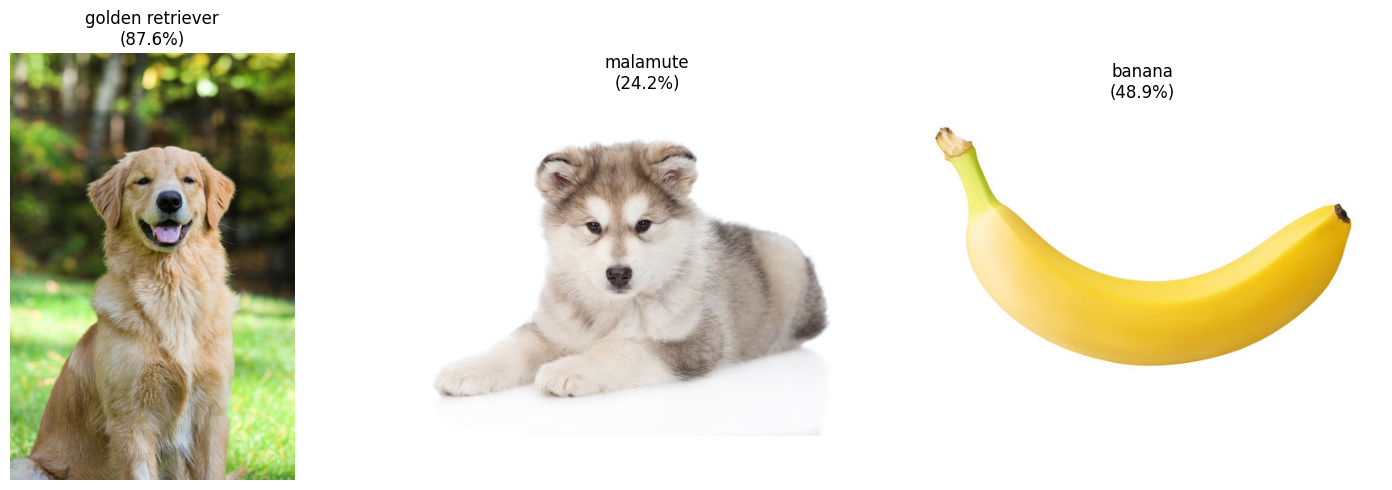

In [7]:
n = len(rutas_imagenes)
fig, ejes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    ejes = [ejes]

for eje, ruta in zip(ejes, rutas_imagenes):
    imagen, resultados = predecir(ruta)

    print(f"\nImagen: {ruta}")
    for etiqueta, prob in resultados:
        print(f"  {etiqueta:25s} {prob * 100:5.2f}%")

    etiqueta_top, prob_top = resultados[0]
    eje.imshow(imagen)
    eje.set_title(f"{etiqueta_top}\n({prob_top * 100:.1f}%)")
    eje.axis("off")

plt.tight_layout()
plt.show()